In [2]:
import sys
import os
curr_dir=os.getcwd()
pardir=os.pardir
sys.path.append(os.path.join(curr_dir, pardir))
sys.path.append(os.path.join(curr_dir, pardir, pardir))
from liset_paper import liset_paper as liset_tk

import numpy as np
import matplotlib.pyplot as plt

from signal_aid import bandpass_filter
import matplotlib.pyplot as plt
# import seaborn as sns
from extract_Nripples.utils_encoding import *


In [38]:
parent=r"E:\neurospark_mat\Download_from_paper"
datasets=os.listdir(parent)
print("Available datasets:")
# for i, dataset in enumerate(datasets):
#     print(f"{i}: {dataset}")
# print()
# dataset=int(input("Dataset to process: "))
dataset=3
dataset_path=os.path.join(parent,datasets[dataset])
print(f"Processing dataset: {datasets[dataset]}")


Available datasets:
Processing dataset: Thy7-2020-11-11_16-05-00


In [39]:
liset=liset=liset_tk(dataset_path, shank=1, downsample=False, start=0, verbose=False)

ripples=liset.ripples_GT

In [67]:
channel=1
window=[5,25] # in seconds
print(ripples[:10])
mask = (ripples[:, 1] >= window[0]*liset.fs) & (ripples[:, 0] <= window[1]*liset.fs)
window_ripples = ripples[mask]
print(f"Ripples in window {window}: {len(window_ripples)}")
channel_data = liset.data[:, channel]

[[  4814   6045]
 [  9033  10000]
 [ 12959  14804]
 [ 23271  24882]
 [ 85127  86266]
 [ 86318  87695]
 [ 90537  92412]
 [ 97187  98681]
 [106591 108291]
 [125181 126483]]
Ripples in window [5, 25]: 36


In [68]:
# Process Data
filtered_channel = bandpass_filter(channel_data, fs=liset.fs, bandpass=(100,250), order=4)
threshold=calculate_threshold(filtered_channel[:120*liset.fs],liset.fs,0.1,0.25,1,plot=False,verbose=False)
print(f"Threshold: {threshold}")
up_down=up_down_channel(filtered_channel,threshold,liset.fs,refractory=0,initial_value=None,return_value=False)
spikes_downsample,spikes_lost=extract_spikes_downsample(up_down,30,)


Threshold: 0.3020455142004901


In [69]:
# Setup shared time window
start_idx = window[0] * liset.fs
end_idx = window[1] * liset.fs
time = np.arange(start_idx, end_idx) / liset.fs
filtered_data = filtered_channel[start_idx:end_idx]
up_down_window = up_down[start_idx:end_idx, :]
up_mask = up_down_window[:, 0] > 0
down_mask = up_down_window[:, 1] > 0
up_spike_times = time[up_mask]
down_spike_times = time[down_mask]
downsampled_start=int(start_idx/30)
downsampled_end=int(end_idx/30)
print(f"Downsampled start: {downsampled_start}, end: {downsampled_end}")
downsampled_time= np.arange(downsampled_start, downsampled_end)/1000

spikes_downsample_window = spikes_downsample[downsampled_start:downsampled_end,:]
ds_up_mask = spikes_downsample_window[:, 0] > 0
ds_down_mask = spikes_downsample_window[:, 1] > 0
ds_up_spike_times = downsampled_time[ds_up_mask]
ds_down_spike_times = downsampled_time[ds_down_mask]


Downsampled start: 5000, end: 25000


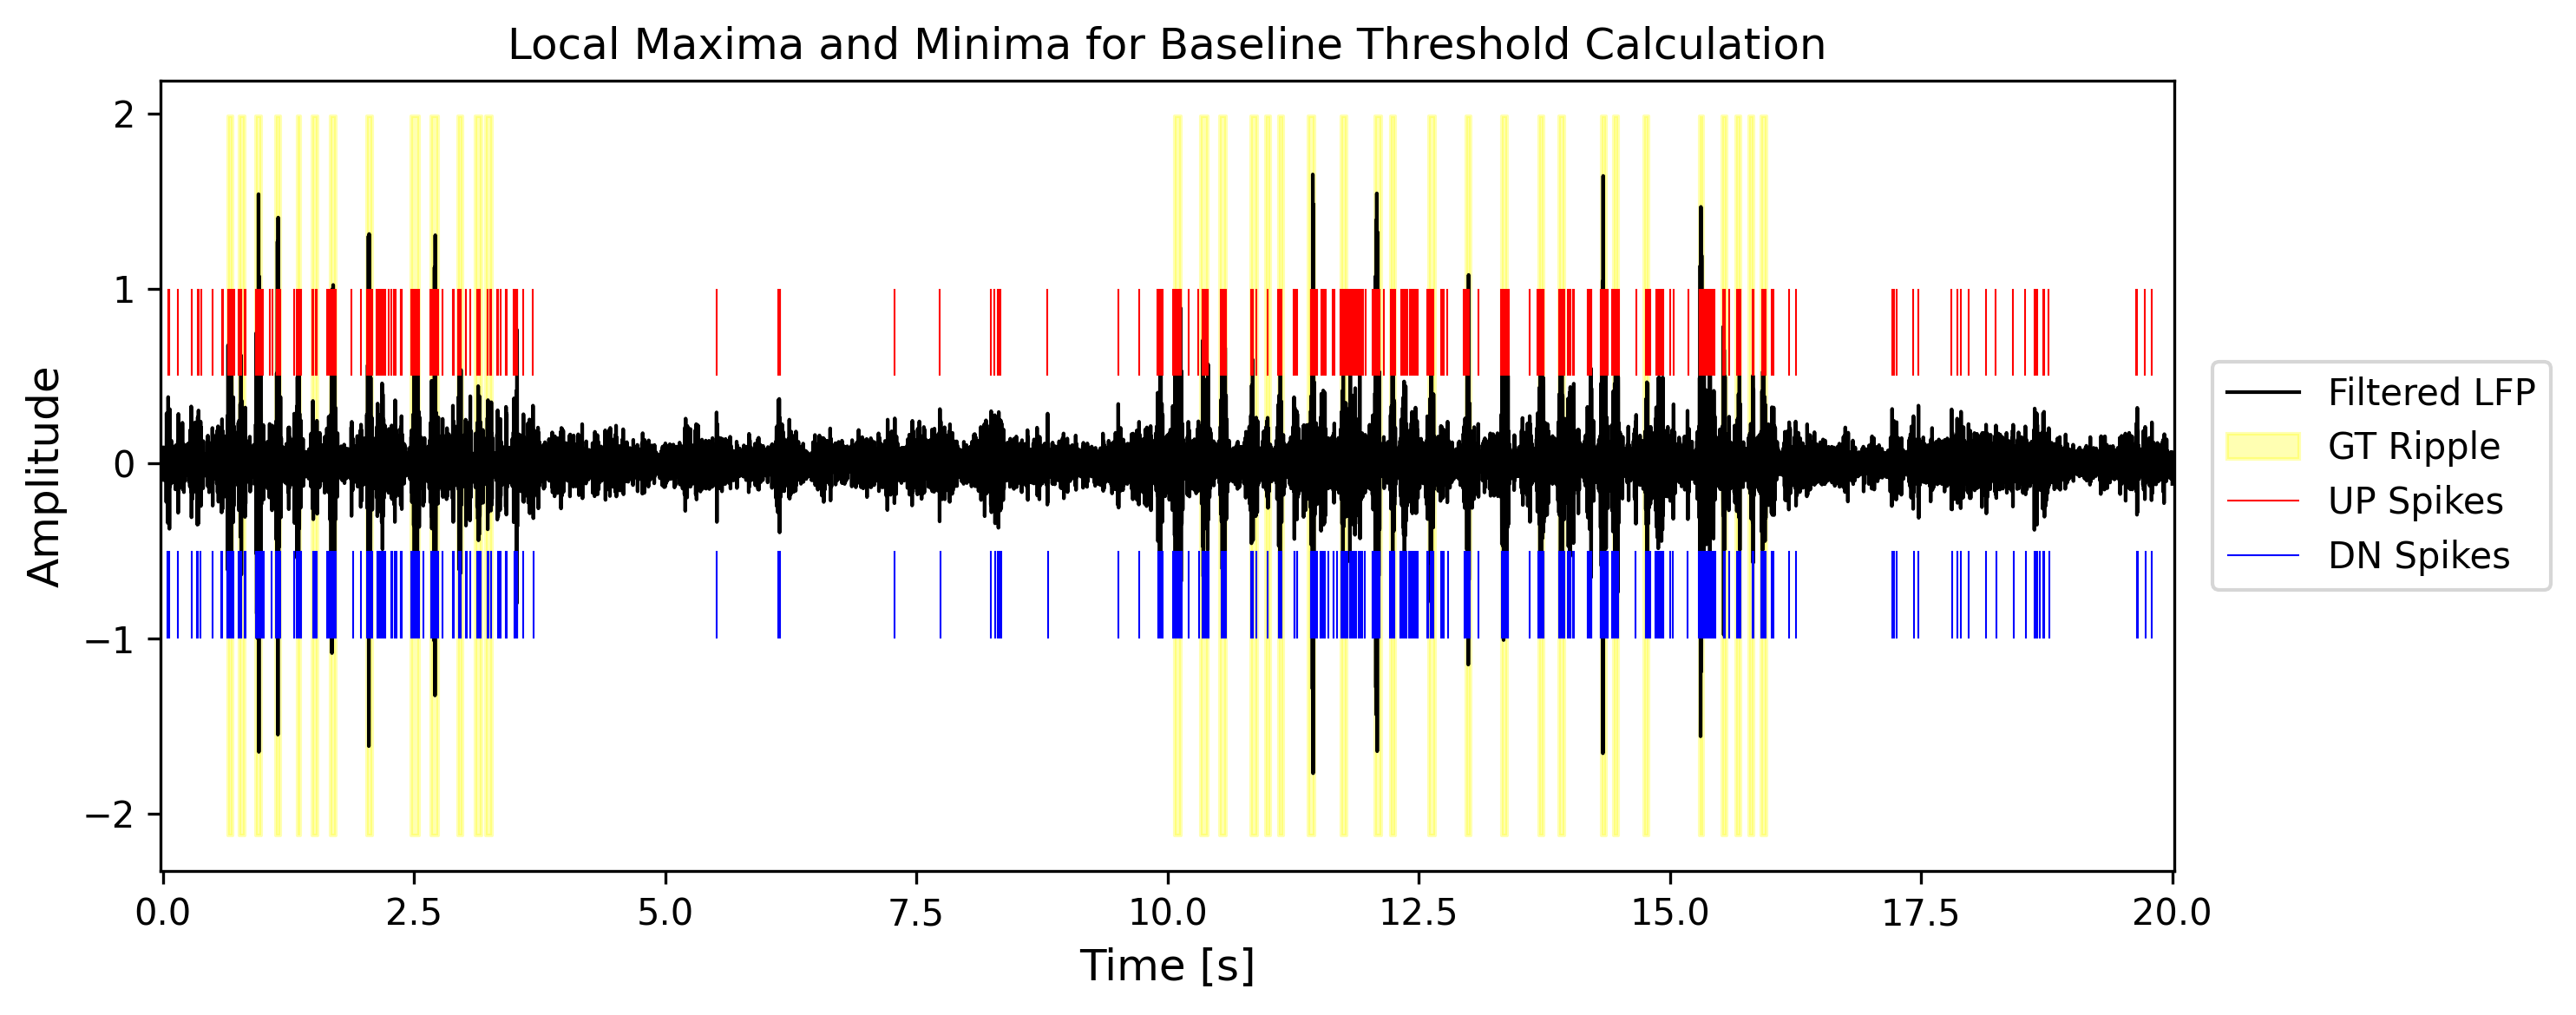

In [70]:
fig, ax = plt.subplots(figsize=(10, 4), dpi=300)

# Time axis starting from 0
time = np.arange(window[0]*liset.fs, window[1]*liset.fs) / liset.fs - window[0]

# Plot filtered data
min_data, max_data = np.min(filtered_data), np.max(filtered_data)
ax.plot(time, filtered_data, label="Filtered LFP", color='black', linewidth=1)

# Highlight ripples
for i, ripple in enumerate(window_ripples):
    start, end = ripple / liset.fs - window[0]
    ax.fill_between([start, end],
                    min_data * 1.2, max_data * 1.2,
                    color="yellow", alpha=0.3,
                    label=f"GT Ripple" if i == 0 else None)

ax.vlines(ds_up_spike_times-window[0], ymin=0.5, ymax=1, color='red', linewidth=0.5,label="UP Spikes")
ax.vlines(ds_down_spike_times-window[0], ymin=-1, ymax=-0.5, color='blue', linewidth=0.5,label="DN Spikes")

# Final plot formatting
ax.set_xlabel("Time [s]",fontsize=12)
ax.set_ylabel("Amplitude",fontsize=12)
ax.set_title("Local Maxima and Minima for Baseline Threshold Calculation")
# ax.set_xticks(np.arange(0, window[1] - window[0] + 0.1, 0.1))
# ax.set_yticks(np.arange(min_data * 1.2, max_data * 1.2, (max_data - min_data) / 5))
ax.set_xlim(-0.02, window[1] - window[0]+0.02)
# ax.set_yticks([-2,-1, 0, 1, 2])
ax.legend(loc='center left', bbox_to_anchor=(1.01, 0.5))
plt.tight_layout()


In [71]:
print(window_ripples/liset.fs - window[0])

[[ 0.64776667  0.69766667]
 [ 0.766       0.8148    ]
 [ 0.92976667  0.97856667]
 [ 1.12933333  1.16946667]
 [ 1.3419      1.3712    ]
 [ 1.4894      1.54256667]
 [ 1.67486667  1.72586667]
 [ 2.03386667  2.08376667]
 [ 2.4699      2.54906667]
 [ 2.67486667  2.73886667]
 [ 2.94386667  2.98183333]
 [ 3.11413333  3.17163333]
 [ 3.22043333  3.27356667]
 [10.07616667 10.1315    ]
 [10.3354     10.3994    ]
 [10.52413333 10.57943333]
 [10.82996667 10.89286667]
 [10.9829     11.02193333]
 [11.10653333 11.14883333]
 [11.40156667 11.46013333]
 [11.73236667 11.78333333]
 [12.06316667 12.1239    ]
 [12.22586667 12.26273333]
 [12.60113333 12.6597    ]
 [12.9764     13.01543333]
 [13.32346667 13.38313333]
 [13.702      13.73886667]
 [13.89506667 13.9482    ]
 [14.3224     14.3636    ]
 [14.44276667 14.48506667]
 [14.7432     14.78333333]
 [15.2931     15.3343    ]
 [15.52193333 15.5675    ]
 [15.6597     15.70306667]
 [15.792      15.83323333]
 [15.9124     15.96336667]]


In [80]:
from collections import OrderedDict

def plot_window_180ms(sub_window,window,title,y_min=None, y_max=None):
    # Create figure and axis for a single plot
    fig, ax = plt.subplots(figsize=(10, 6), dpi=300)

    # Get absolute time bounds
    sub_start_time = sub_window[0] + window[0]
    sub_end_time = sub_window[1] + window[0]

    # Convert subwindow time range to indices
    start_idx = int(sub_start_time * liset.fs)
    end_idx = int(sub_end_time * liset.fs)

    # Time vector in ms
    time = (np.arange(start_idx, end_idx) / liset.fs - sub_start_time) * 1000

    # Extract LFP
    sub_filtered = filtered_channel[start_idx:end_idx]
    min_data, max_data = np.min(sub_filtered), np.max(sub_filtered)
    y_pad = (max_data - min_data) * 0.2
    if y_min is None or y_max is None:
        y_min, y_max = min_data - y_pad, max_data + y_pad
        print(f"Y limits: {y_min}, {y_max}")

    # 30kHz spikes
    up_down_window = up_down[start_idx:end_idx, :]
    up_mask = up_down_window[:, 0] > 0
    down_mask = up_down_window[:, 1] > 0
    up_spike_times = time[up_mask]
    down_spike_times = time[down_mask]

    # 1kHz downsampled spikes
    down_start = int(start_idx / 30)
    down_end = int(end_idx / 30)
    down_time = (np.arange(down_start, down_end) / 1000 - sub_start_time) * 1000
    ds_window = spikes_downsample[down_start:down_end, :]
    ds_up_mask = ds_window[:, 0] > 0
    ds_down_mask = ds_window[:, 1] > 0
    ds_up_times = down_time[ds_up_mask]
    ds_down_times = down_time[ds_down_mask]

    # Plot LFP
    ax.plot(time, sub_filtered, color='black', linewidth=1)

    # Plot spikes
    spike_height = (y_max - y_min) * 0.15
    print(spike_height)

    # Plot UP spikes in upper band
    ax.vlines(ds_up_times,
            ymin=y_max - spike_height*2,
            ymax=y_max-spike_height,
            color='red', linewidth=1, label="UP Spikes")

    # Plot DOWN spikes in lower band
    ax.vlines(ds_down_times,
            ymin=y_min+spike_height,
            ymax=y_min + spike_height*2,
            color='blue', linewidth=1, label="DN Spikes")
    # Plot GT ripples and timing
    for ripple in window_ripples:
        ripple_start_time = ripple[0] / liset.fs
        ripple_end_time = ripple[1] / liset.fs
        if ripple_end_time >= sub_start_time and ripple_start_time <= sub_end_time:
            rel_start = (ripple_start_time - sub_start_time) * 1000
            rel_end = (ripple_end_time - sub_start_time) * 1000
            ax.fill_between(
                [rel_start, rel_end],
                y_min,y_max,
                color='yellow', alpha=0.3,
                label="GT Ripple"
            )
            # If the whole ripple is within the window
            if ripple_start_time >= sub_start_time and ripple_end_time <= sub_end_time:
                gt_timing = rel_start + 31
                ax.vlines(gt_timing, ymin=y_min, ymax=y_max, color="green", linestyle="--",linewidth=2, label="GT Timing")
                ax.fill_between([gt_timing - 20, gt_timing + 20],
                                y_min, y_max, color='green', alpha=0.2, label="Tolerance")

    # Formatting
    ax.set_title(title,fontsize=14,fontweight='bold')
    ax.set_ylabel("Amplitude",fontsize=12)
    ax.set_xlabel("Time [ms]",fontsize=12)
    ax.set_xlim(-10, (sub_window[1] - sub_window[0]) * 1000 + 10)
    ax.set_ylim(y_min, y_max)
    ax.set_xticks(np.arange(0, (sub_window[1] - sub_window[0]) * 1000 + 10,20))
    ax.set_yticks(np.arange(-1.8,2.0,0.4))
    # Add grid
    ax.grid(True,axis="x", linestyle='--', linewidth=0.3, alpha=0.5)

    # Remove duplicate legend entries
    handles, labels = ax.get_legend_handles_labels()
    unique = list(OrderedDict.fromkeys(zip(labels, handles)))
    labels, handles = zip(*unique)

    # Add legend
    # ax.legend(handles, labels, loc='upper right', frameon=True, edgecolor='gray')

    plt.tight_layout()
    plt.show()
    return y_min, y_max


Y limits: -1.8512947728986227, 1.830269042443041
0.5522345723012495


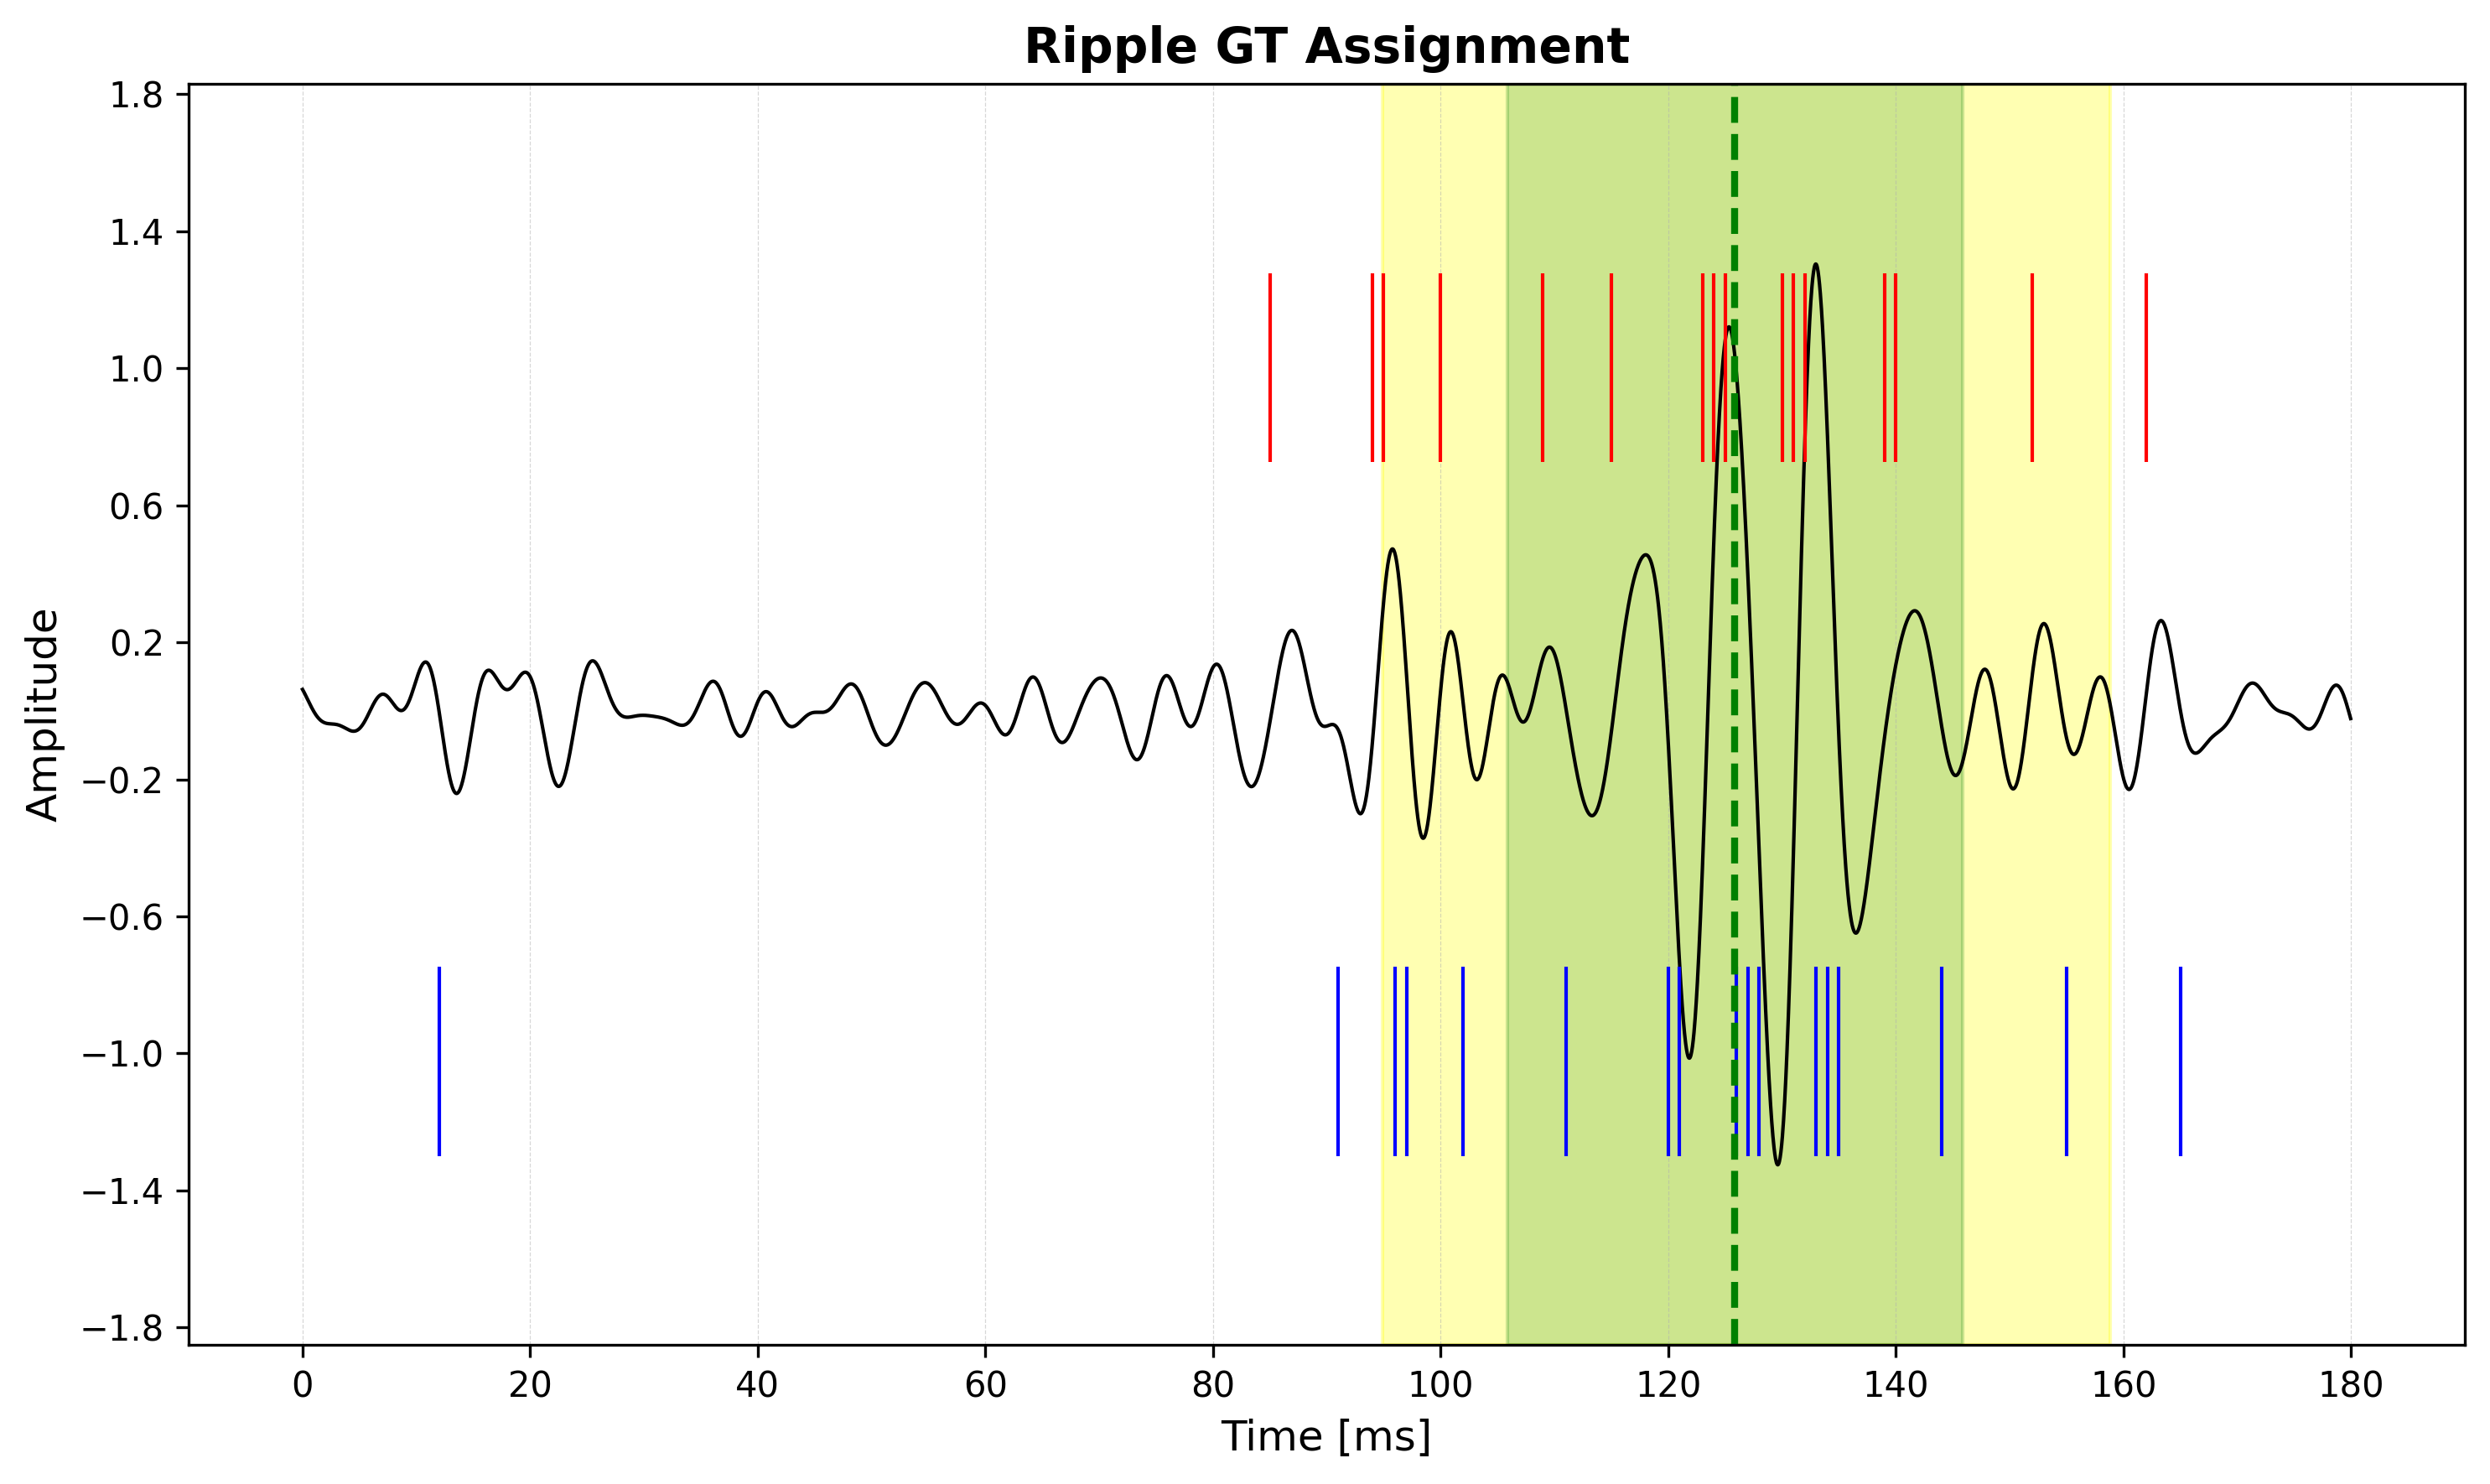

In [81]:


# Define the subwindow relative to `window`
sub_window = [2.58, 2.76]
title = "Ripple GT Assignment"
y_min,y_max=plot_window_180ms(sub_window,window,title)

0.5522345723012495


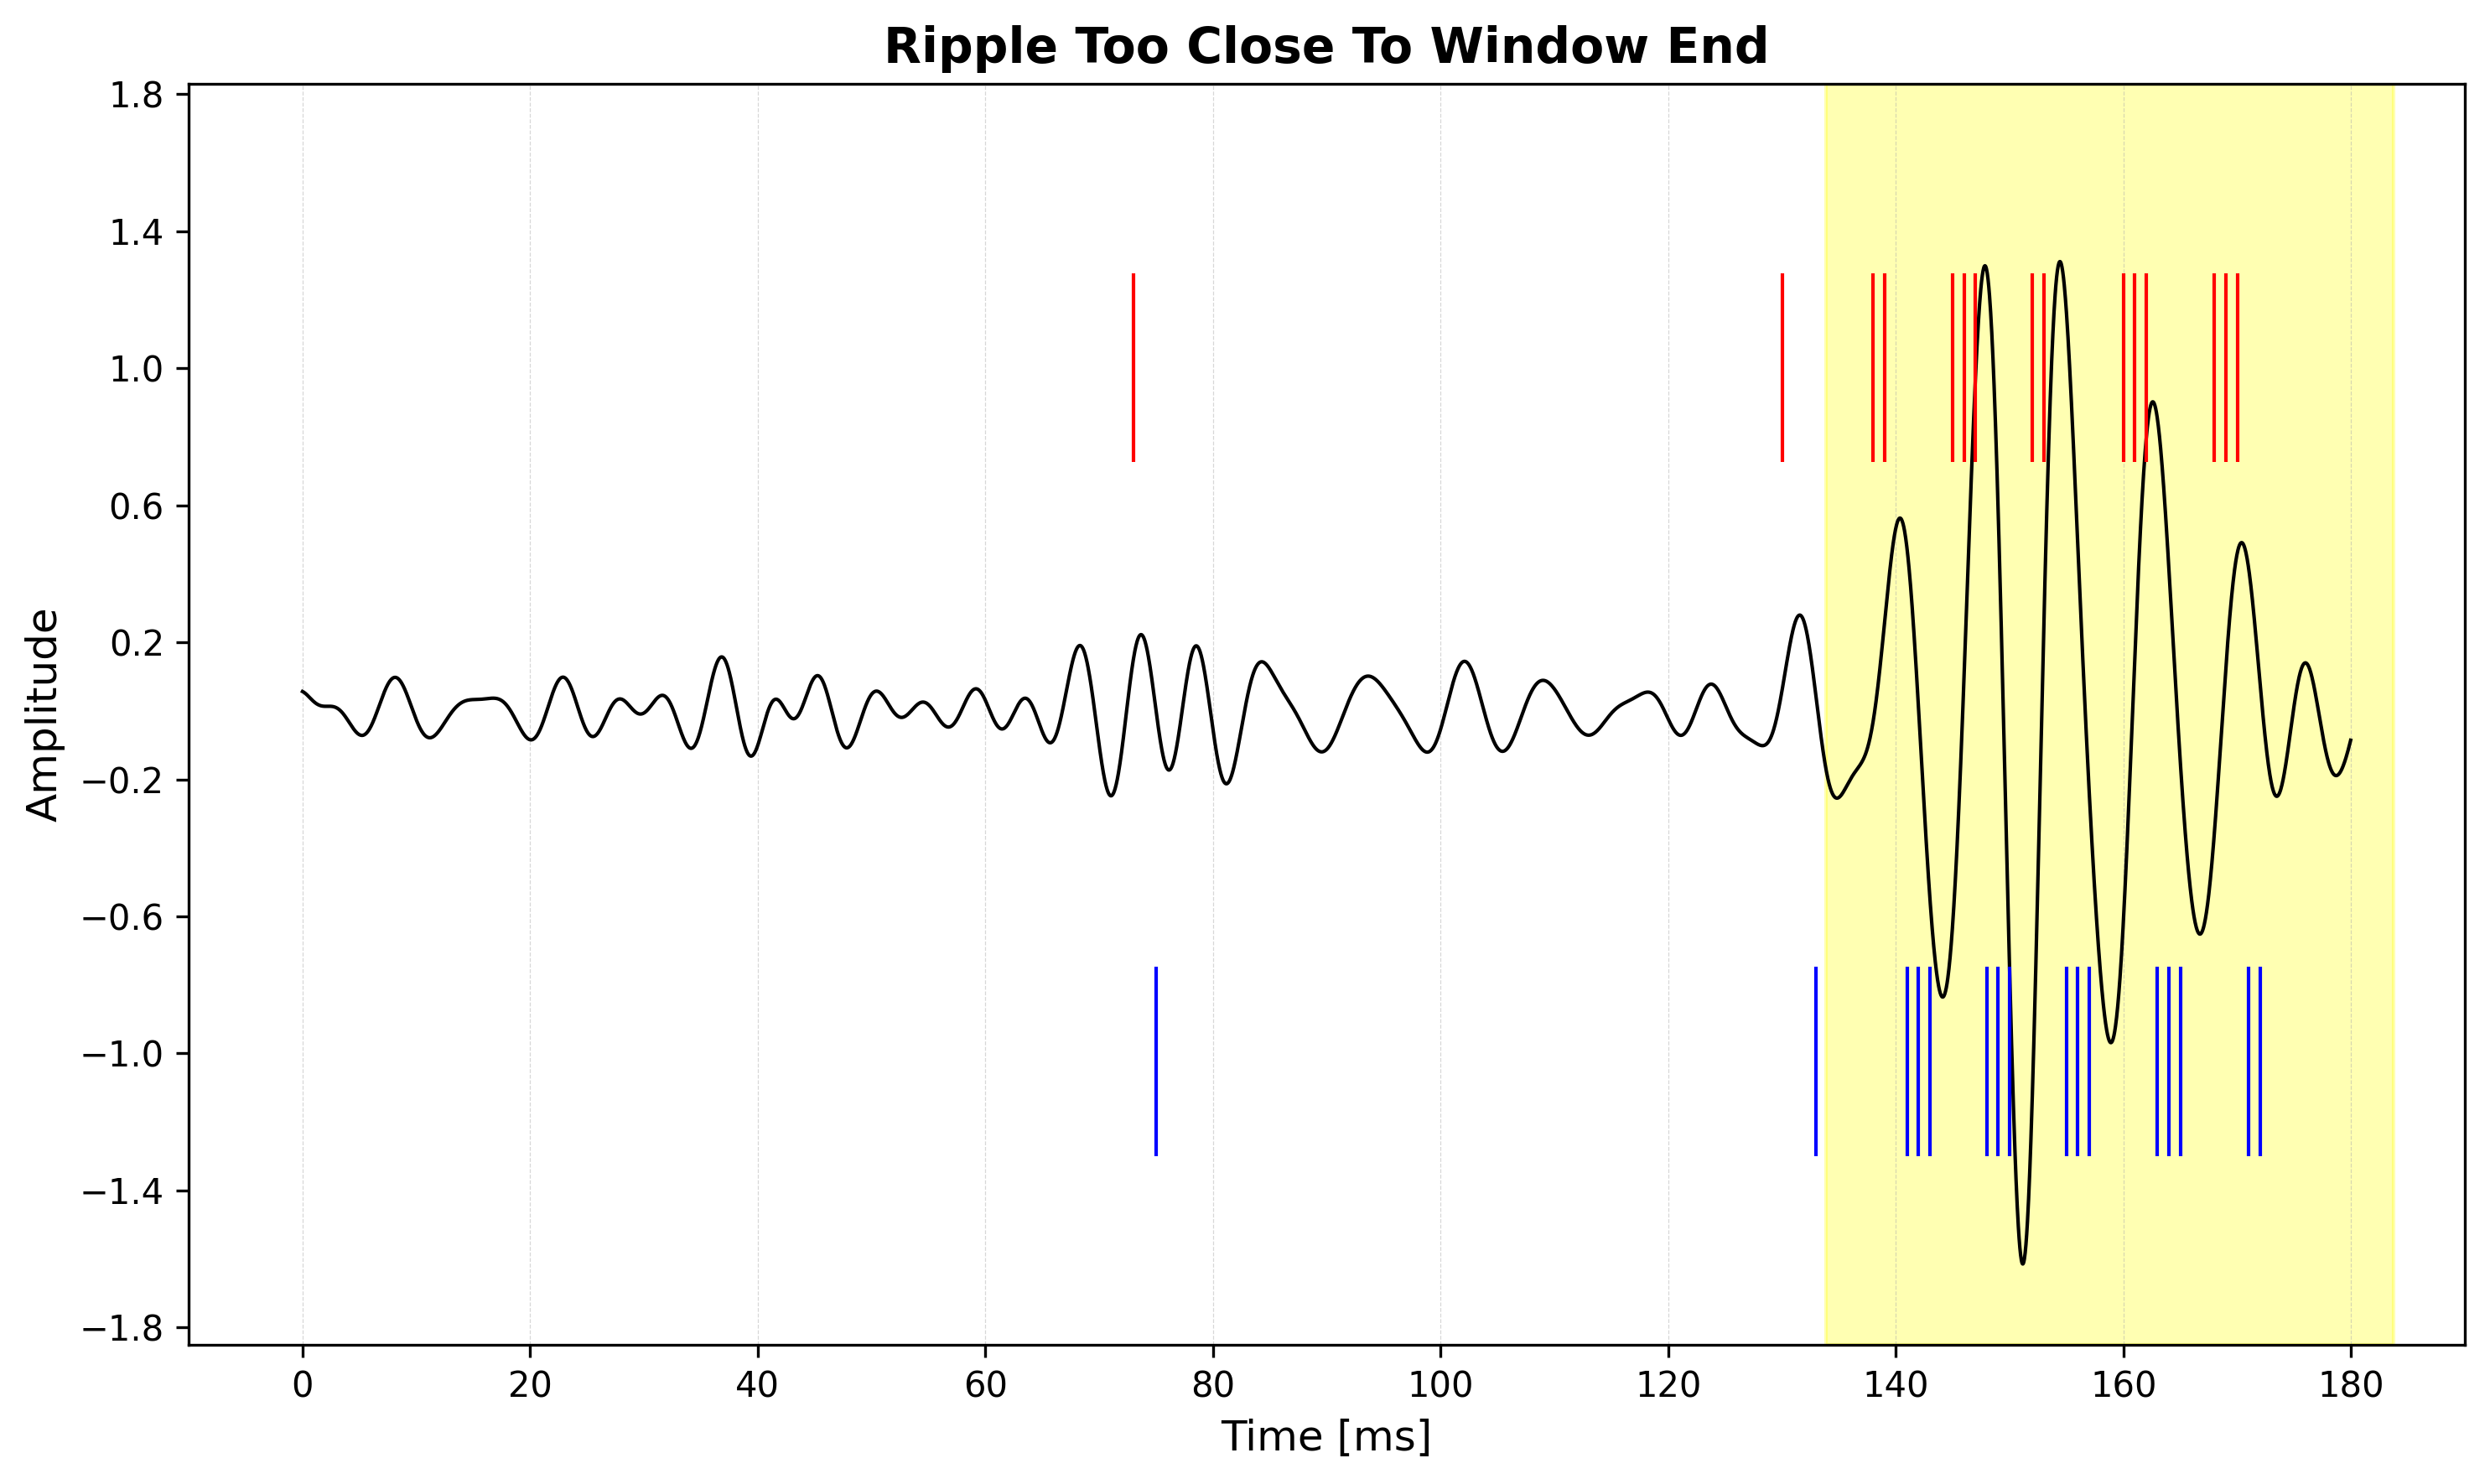

(-1.8512947728986227, 1.830269042443041)

In [82]:
# Start too close to window end

# Define the subwindow relative to `window`
sub_window = [1.9,2.08]
title = "Ripple Too Close To Window End"

plot_window_180ms(sub_window,window,title,y_min=y_min, y_max=y_max)

0.5522345723012495


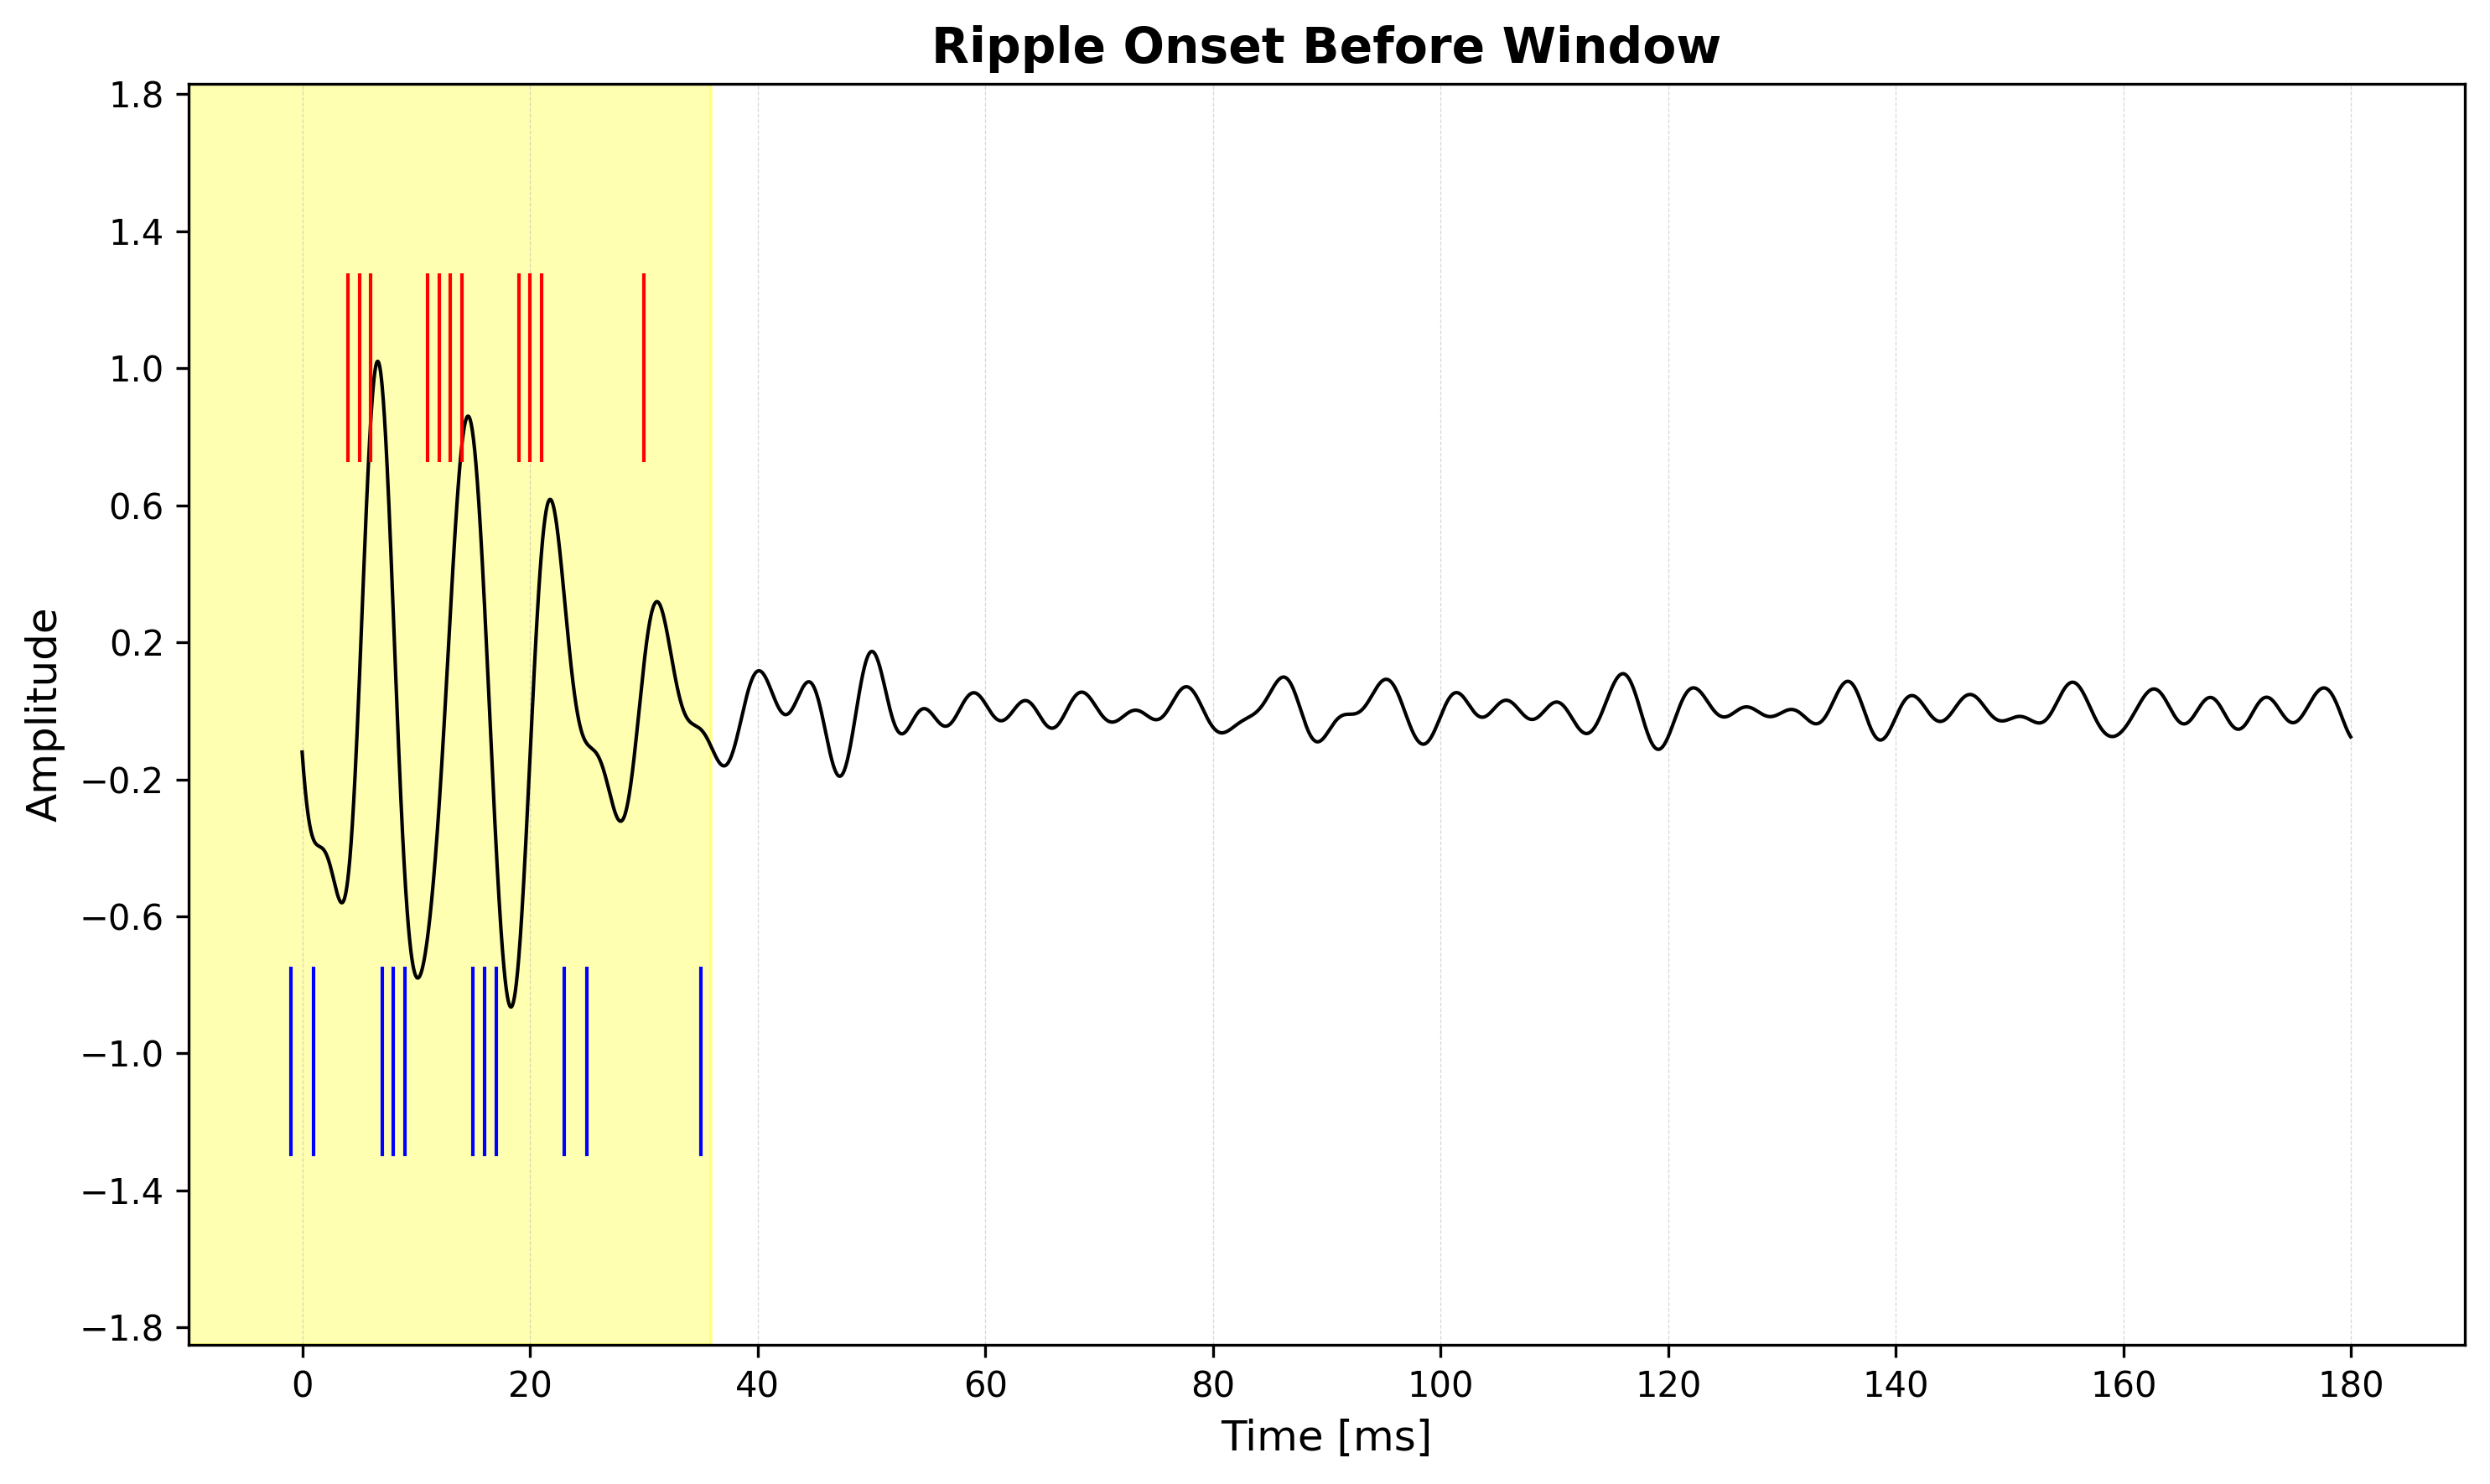

(-1.8512947728986227, 1.830269042443041)

In [83]:

# Define the subwindow relative to `window`
sub_window = [1.69,1.69+0.18]
title = "Ripple Onset Before Window"
plot_window_180ms(sub_window,window,title,y_min=y_min, y_max=y_max)

0.5522345723012495


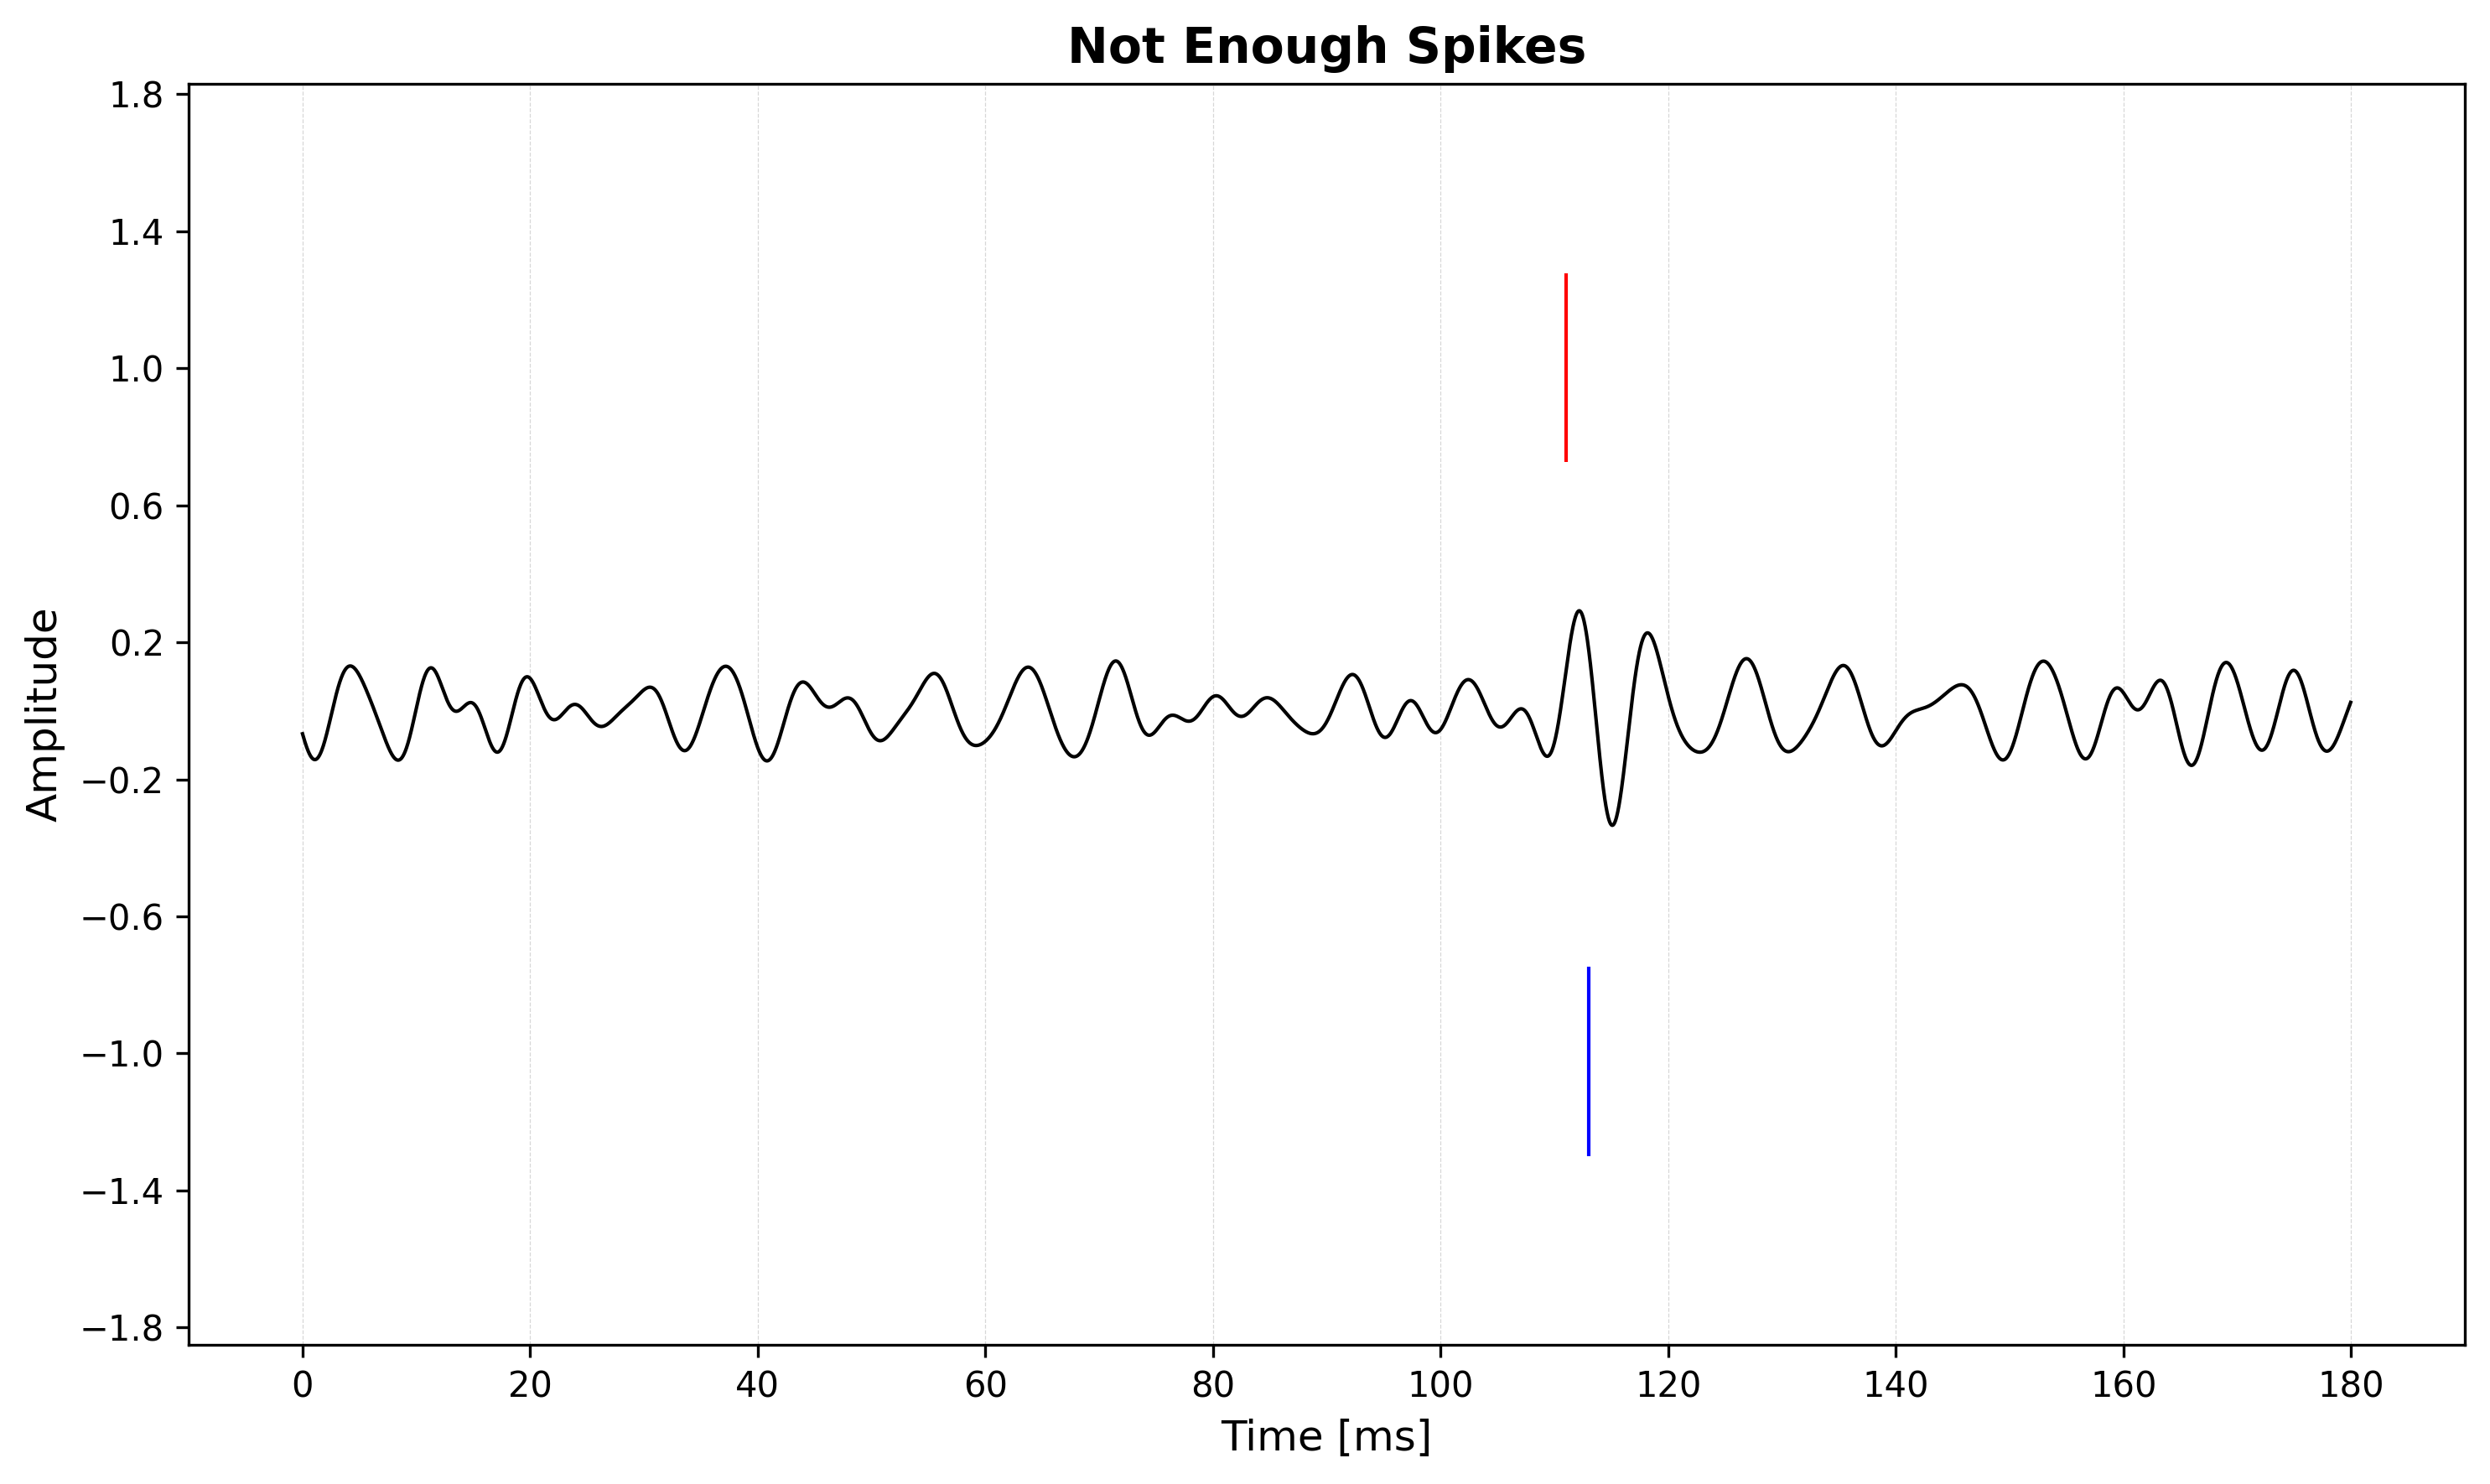

(-1.8512947728986227, 1.830269042443041)

In [85]:
# Define the subwindow relative to `window`
window_size=0.18
start=5.4
sub_window = [start,start+window_size]
title = "Not Enough Spikes"
plot_window_180ms(sub_window,window,title,y_min=y_min, y_max=y_max)